In [15]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
import matplotlib.pyplot as plt
import os

In [16]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [17]:
dataset = os.path.join('datasets', 'AABA_2006-01-01_to_2018-01-01.csv')
df = pd.read_csv(dataset)
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   str    
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   str    
dtypes: float64(4), int64(1), str(2)
memory usage: 206.5 KB


In [19]:
data = df[['Open']]
data

,Open
0,39.69
1,41.22
2,40.93
3,42.88
4,43.10
...,...
3014,71.42
3015,70.94
3016,69.77
3017,70.12


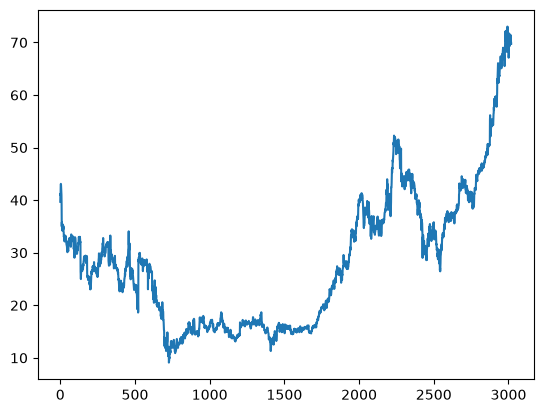

In [20]:
plt.plot(data['Open'])

In [21]:
X = data['Open'].values

In [22]:
X[:10]

array([39.69, 41.22, 40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  ,
       39.09])

In [23]:
X_train, X_test = X[:2500], X[2500:]

In [24]:
model = Sequential()
model.add(SimpleRNN(units=64, activation='tanh'))
model.add(Dense(1))

I0000 00:00:1783845139.638605   25160 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [25]:
model.compile(loss='mean_absolute_error', optimizer='adam')

In [27]:
XT, yT = [], []
for i in range(len(X_train) - 90):
    d = i + 90
    XT.append(X_train[i:d,])
    yT.append(X_train[d])

In [28]:
Xt, yt = [], []
for i in range(len(X_test) - 90):
    d = i + 90
    Xt.append(X_test[i:d,])
    yt.append(X_test[d])

In [29]:
XT = np.array(XT)
Xt = np.array(Xt)

In [30]:
XT.shape

(2410, 90)

In [31]:
XT[2]

array([40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  , 39.09, 35.01,
       35.82, 34.44, 34.22, 34.55, 35.43, 34.94, 35.26, 35.06, 35.2 ,
       34.45, 35.01, 34.  , 33.9 , 33.01, 33.24, 33.01, 32.58, 32.21,
       32.14, 32.62, 33.3 , 32.88, 32.9 , 32.49, 33.01, 33.2 , 33.11,
       32.63, 32.21, 32.01, 31.7 , 31.53, 31.42, 31.31, 31.05, 30.4 ,
       30.72, 30.1 , 31.25, 30.77, 30.34, 30.38, 30.42, 30.33, 31.52,
       32.28, 31.84, 31.45, 32.44, 32.75, 32.45, 32.41, 31.69, 32.3 ,
       32.12, 32.85, 32.28, 32.45, 31.44, 31.14, 31.16, 31.17, 33.47,
       33.48, 33.36, 33.01, 32.99, 32.3 , 32.79, 32.88, 32.99, 32.2 ,
       32.4 , 32.4 , 32.63, 33.09, 32.68, 32.48, 31.96, 30.71, 30.85])

In [32]:
XT = np.reshape(XT, (XT.shape[0], XT.shape[1], 1))
Xt = np.reshape(Xt, (Xt.shape[0], Xt.shape[1], 1))

In [33]:
XT.shape

(2410, 90, 1)

In [34]:
XT[1]

array([[41.22],
       [40.93],
       [42.88],
       [43.1 ],
       [42.96],
       [42.19],
       [41.92],
       [41.  ],
       [39.09],
       [35.01],
       [35.82],
       [34.44],
       [34.22],
       [34.55],
       [35.43],
       [34.94],
       [35.26],
       [35.06],
       [35.2 ],
       [34.45],
       [35.01],
       [34.  ],
       [33.9 ],
       [33.01],
       [33.24],
       [33.01],
       [32.58],
       [32.21],
       [32.14],
       [32.62],
       [33.3 ],
       [32.88],
       [32.9 ],
       [32.49],
       [33.01],
       [33.2 ],
       [33.11],
       [32.63],
       [32.21],
       [32.01],
       [31.7 ],
       [31.53],
       [31.42],
       [31.31],
       [31.05],
       [30.4 ],
       [30.72],
       [30.1 ],
       [31.25],
       [30.77],
       [30.34],
       [30.38],
       [30.42],
       [30.33],
       [31.52],
       [32.28],
       [31.84],
       [31.45],
       [32.44],
       [32.75],
       [32.45],
       [32.41],
       [

In [35]:
yT = np.array(yT)
yt = np.array(yt)

In [36]:
history = model.fit(XT, yT, epochs=100, batch_size=20)

Epoch 1/100


I0000 00:00:1783845425.437069   28115 service.cc:153] XLA service 0x776904030430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783845425.437088   28115 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783845425.467377   28115 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783845425.599305   28115 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783845425.612528   28115 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1200_grad_1391_const_0__.15.clone.clone.clone.clone.clone
I0000 00:00:1783845425.623915   28115 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of vali

 25/121 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.7629

I0000 00:00:1783845427.059794   28115 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.7444

I0000 00:00:1783845427.823014   28107 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1200_grad_1391_const_0__.15.clone.clone.clone.clone.clone


121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 16.5446
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.7253
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6640
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4013
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2950
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6440
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2617
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0319
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8840
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7485
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6879
Epoch 12/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6125
Epoch 13/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5789
Epoch 14/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5558
Epoch 15/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [37]:
model.evaluate(Xt, yt)

I0000 00:00:1783845495.571004   28109 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783845495.874230   34153 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 12 bytes spill stores, 12 bytes spill loads



14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.4085


4.408538341522217

In [38]:
XTPredicted = model.predict(XT)
XtPredicted = model.predict(Xt)
XFinal = np.concatenate([XTPredicted, XtPredicted], axis=0)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


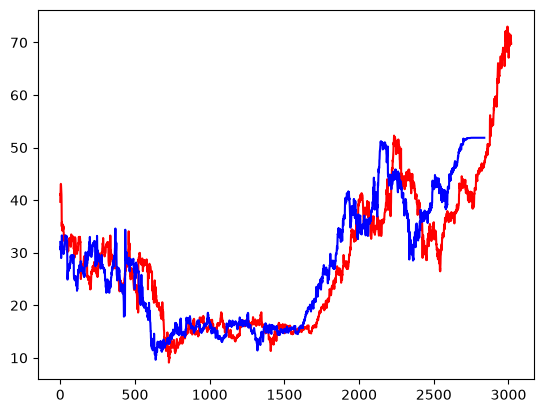

In [39]:
plt.plot(X, color='red')
plt.plot(XFinal, color='blue')